https://www.kaggle.com/datasets/heeraldedhia/bike-buyers

In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.feature_selection import SelectKBest, chi2, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [239]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your CSV file
file_path = '/content/drive/My Drive/Customer_Demographics_Bike_Purchase.csv'  # Change this to your file path

# Read the CSV file
df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


# **Data Preprocessing**

In [240]:
print(df['Gender'].value_counts())

Gender
Male      500
Female    489
Name: count, dtype: int64


In [241]:
print(df['Education'].value_counts())

Education
Bachelors              306
Partial College        265
High School            179
Graduate Degree        174
Partial High School     76
Name: count, dtype: int64


In [242]:
print(df['Occupation'].value_counts())

Occupation
Professional      276
Skilled Manual    255
Clerical          177
Management        173
Manual            119
Name: count, dtype: int64


In [243]:
print(df["Marital Status"].value_counts())

Marital Status
Married    535
Single     458
Name: count, dtype: int64


In [244]:
print(df["Region"].value_counts())

Region
North America    508
Europe           300
Pacific          192
Name: count, dtype: int64


In [245]:
print(df["Purchased Bike"].value_counts())

Purchased Bike
No     519
Yes    481
Name: count, dtype: int64


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital Status    993 non-null    object 
 2   Gender            989 non-null    object 
 3   Income            994 non-null    float64
 4   Children          992 non-null    float64
 5   Education         1000 non-null   object 
 6   Occupation        1000 non-null   object 
 7   Home Owner        996 non-null    object 
 8   Cars              991 non-null    float64
 9   Commute Distance  1000 non-null   object 
 10  Region            1000 non-null   object 
 11  Age               992 non-null    float64
 12  Purchased Bike    1000 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 101.7+ KB


<Axes: >

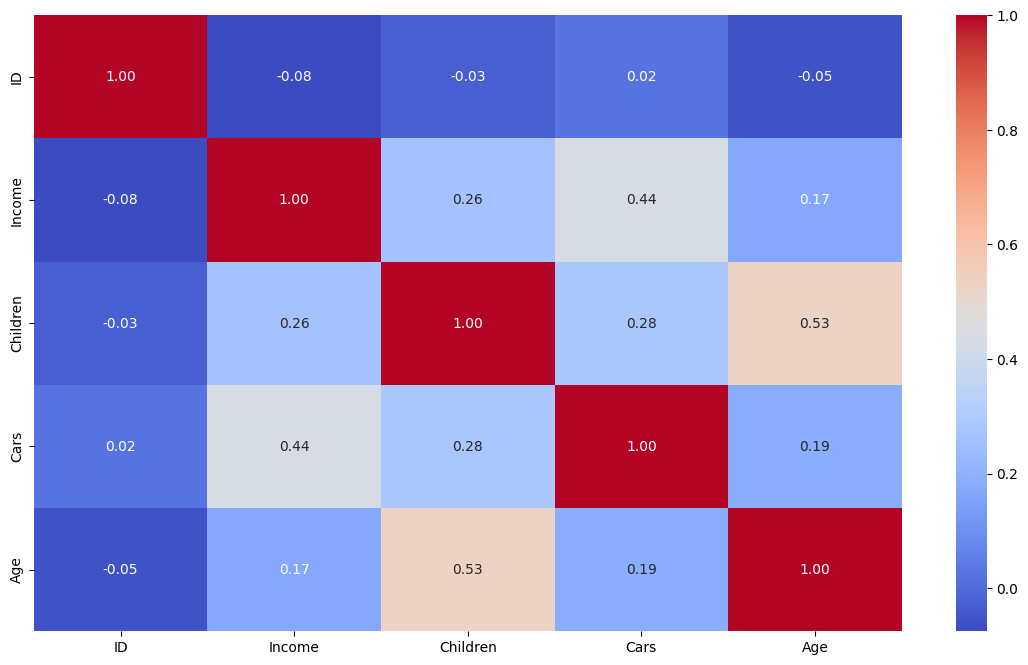

In [247]:
numeric_attribute = df.select_dtypes(include = ['int64', 'float64'])
plt.figure(figsize=(14, 8))
sns.heatmap(numeric_attribute.corr(), annot=True, cmap='coolwarm', fmt='.2f')

In [248]:
## Finding out correlation of each attribute with each other
cor_data = numeric_attribute.corr().round(4)
for k in numeric_attribute:
    print(f"\n-------{k}:")
    print(cor_data[k].sort_values(ascending=False))


-------ID:
ID          1.0000
Cars        0.0221
Children   -0.0287
Age        -0.0542
Income     -0.0751
Name: ID, dtype: float64

-------Income:
Income      1.0000
Cars        0.4400
Children    0.2611
Age         0.1708
ID         -0.0751
Name: Income, dtype: float64

-------Children:
Children    1.0000
Age         0.5317
Cars        0.2802
Income      0.2611
ID         -0.0287
Name: Children, dtype: float64

-------Cars:
Cars        1.0000
Income      0.4400
Children    0.2802
Age         0.1864
ID          0.0221
Name: Cars, dtype: float64

-------Age:
Age         1.0000
Children    0.5317
Cars        0.1864
Income      0.1708
ID         -0.0542
Name: Age, dtype: float64


*There is no multicollinearity*





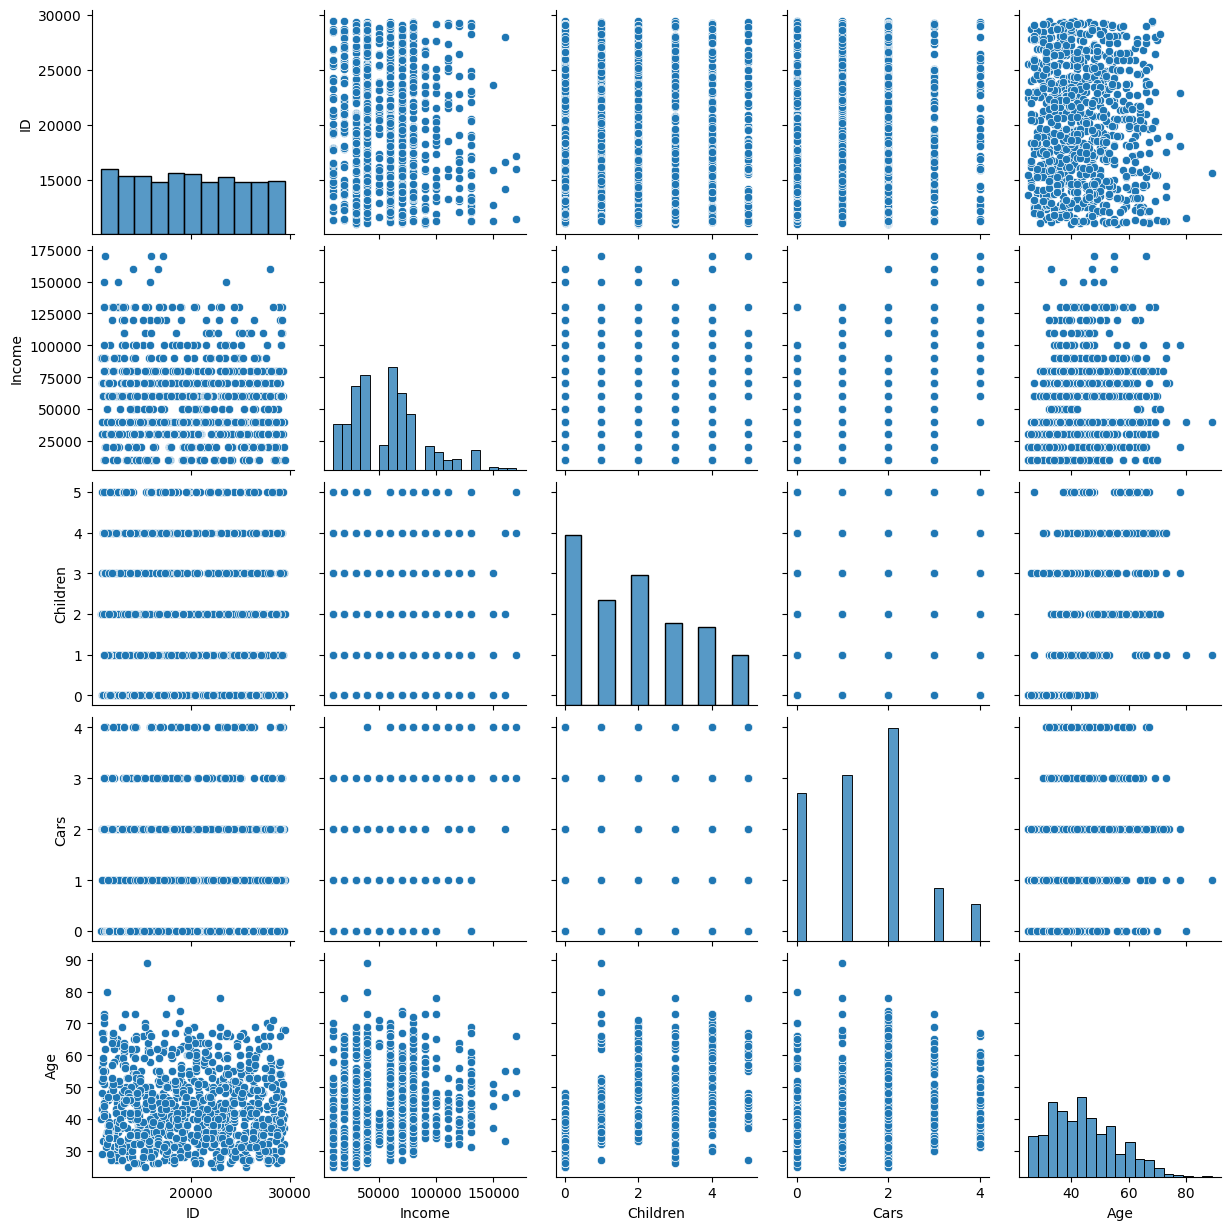

In [249]:
sns.pairplot(df)

In [250]:
## Checking For Duplicate Values
df.duplicated().sum()

0

In [251]:
## Checking for missing values
df.isnull().sum()

,0
ID,0
Marital Status,7
Gender,11
Income,6
Children,8
Education,0
Occupation,0
Home Owner,4
Cars,9
Commute Distance,0


In [252]:
df.dropna(inplace=True)

In [253]:
# data after removing missing values
df.isnull().sum()

,0
ID,0
Marital Status,0
Gender,0
Income,0
Children,0
Education,0
Occupation,0
Home Owner,0
Cars,0
Commute Distance,0


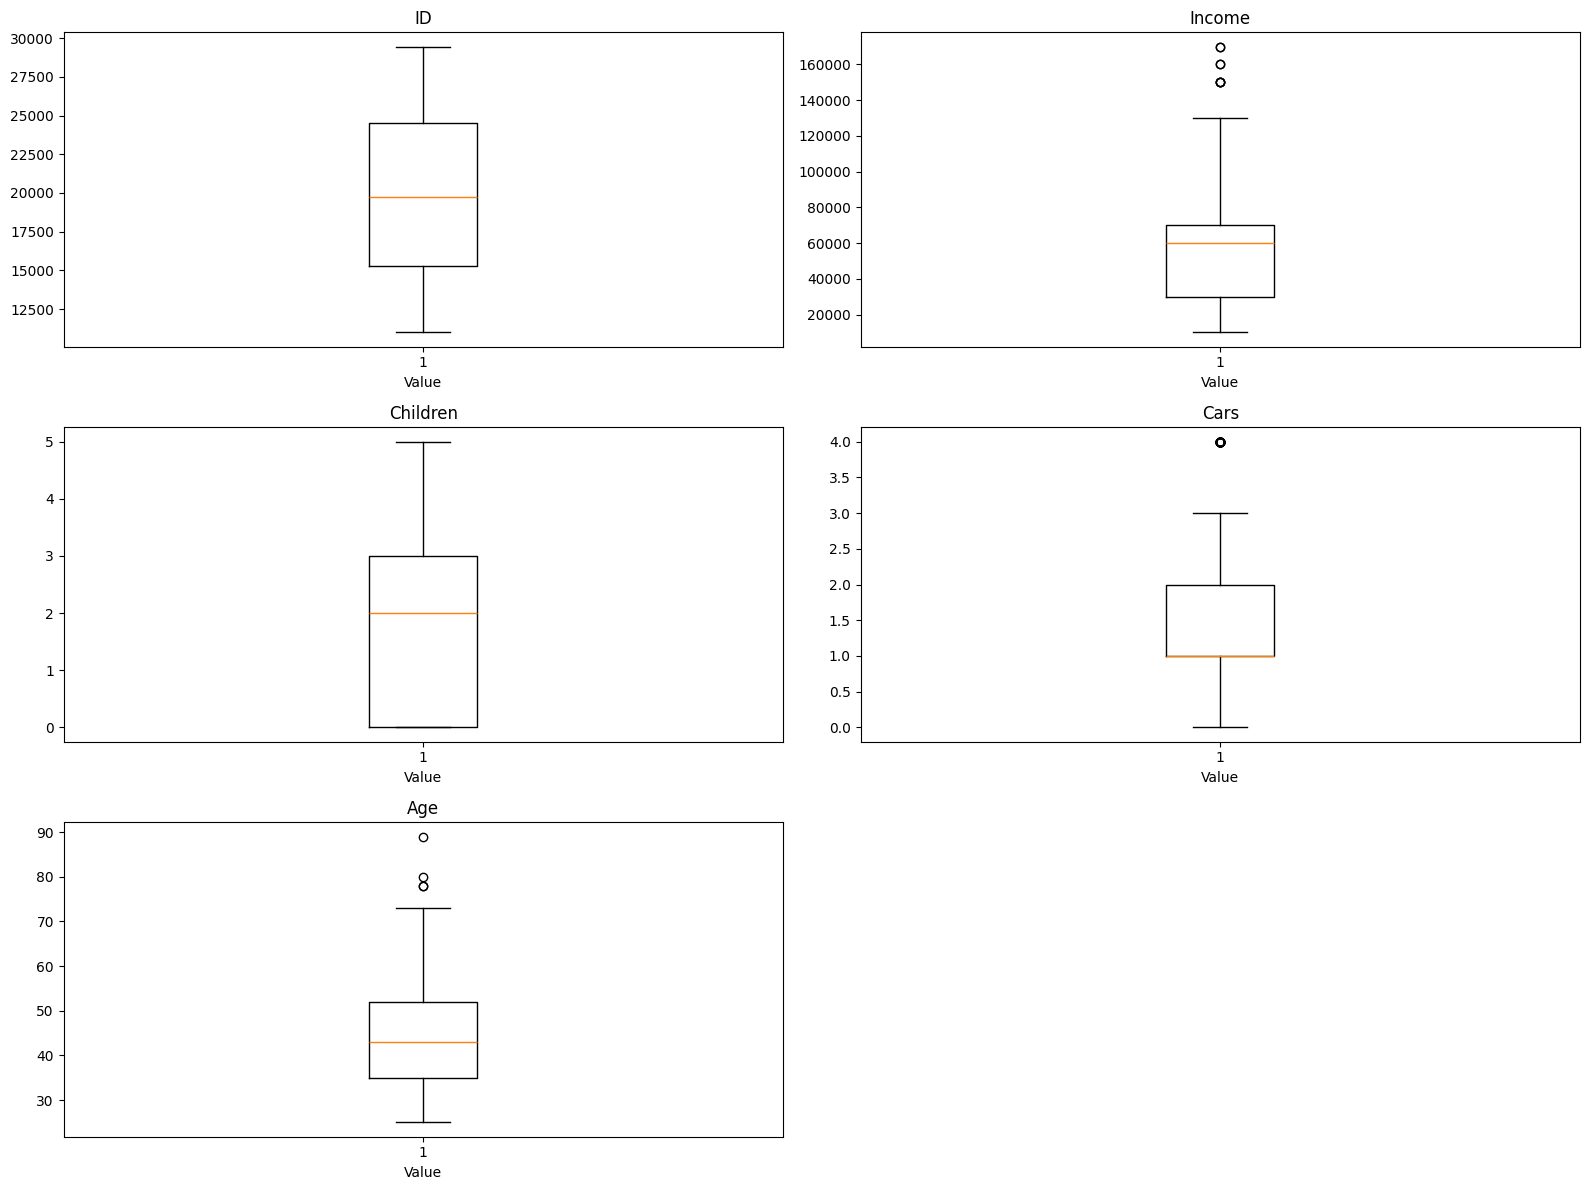

In [254]:
import math
nc = df.select_dtypes(include = ['int64', 'float64'])
# Calculate the number of rows and columns for subplots
num_cols = len(nc.columns)
num_rows = math.ceil(num_cols / 2)  # Adjust the number of columns per row as needed

plt.figure(figsize=(16, 4 * num_rows))

for i, column in enumerate(nc.columns):
    plt.subplot(num_rows, 2, i+1)

    plt.boxplot(nc[column])

    plt.title(column)

    plt.xlabel('Value')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [255]:
dfb = df.copy()
dfb.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
5,13507,Married,Female,10000.0,2.0,Partial College,Manual,Yes,0.0,1-2 Miles,Europe,50.0,No


In [256]:
z_scores = stats.zscore(dfb[['Income', 'Age']])
threshold = 3
outliers = (abs(z_scores) > threshold).any(axis=1)
rows_with_outliers = dfb[outliers]
print("Rows with outliers:")
rows_with_outliers

Rows with outliers:


,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
43,17185,Married,Female,170000.0,4.0,Partial College,Professional,No,3.0,5-10 Miles,Europe,48.0,Yes
121,15922,Married,Male,150000.0,2.0,High School,Professional,Yes,4.0,0-1 Miles,Europe,48.0,No
178,14191,Married,Male,160000.0,4.0,Partial College,Professional,No,2.0,10+ Miles,Europe,55.0,Yes
259,12705,Married,Male,150000.0,0.0,Bachelors,Management,Yes,4.0,0-1 Miles,Pacific,37.0,Yes
321,16675,Single,Female,160000.0,0.0,Graduate Degree,Management,No,3.0,0-1 Miles,Pacific,47.0,Yes
356,23608,Married,Female,150000.0,3.0,High School,Professional,Yes,3.0,0-1 Miles,Europe,51.0,Yes
375,15628,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,1.0,0-1 Miles,Europe,89.0,No
401,11555,Married,Female,40000.0,1.0,Bachelors,Clerical,Yes,0.0,0-1 Miles,Europe,80.0,No
829,16009,Single,Male,170000.0,1.0,Graduate Degree,Management,No,4.0,0-1 Miles,North America,66.0,No
993,11292,Single,Male,150000.0,1.0,Partial College,Professional,No,3.0,0-1 Miles,North America,44.0,Yes


In [257]:
z_scores = stats.zscore(dfb[['Income', 'Age']])
threshold = 3
outliers = (abs(z_scores) > threshold).any(axis=1)
average_income = dfb['Income'].mean()
average_age = dfb['Age'].mean()
dfb.loc[outliers, 'Income'] = average_income
dfb.loc[outliers, 'Age'] = average_age

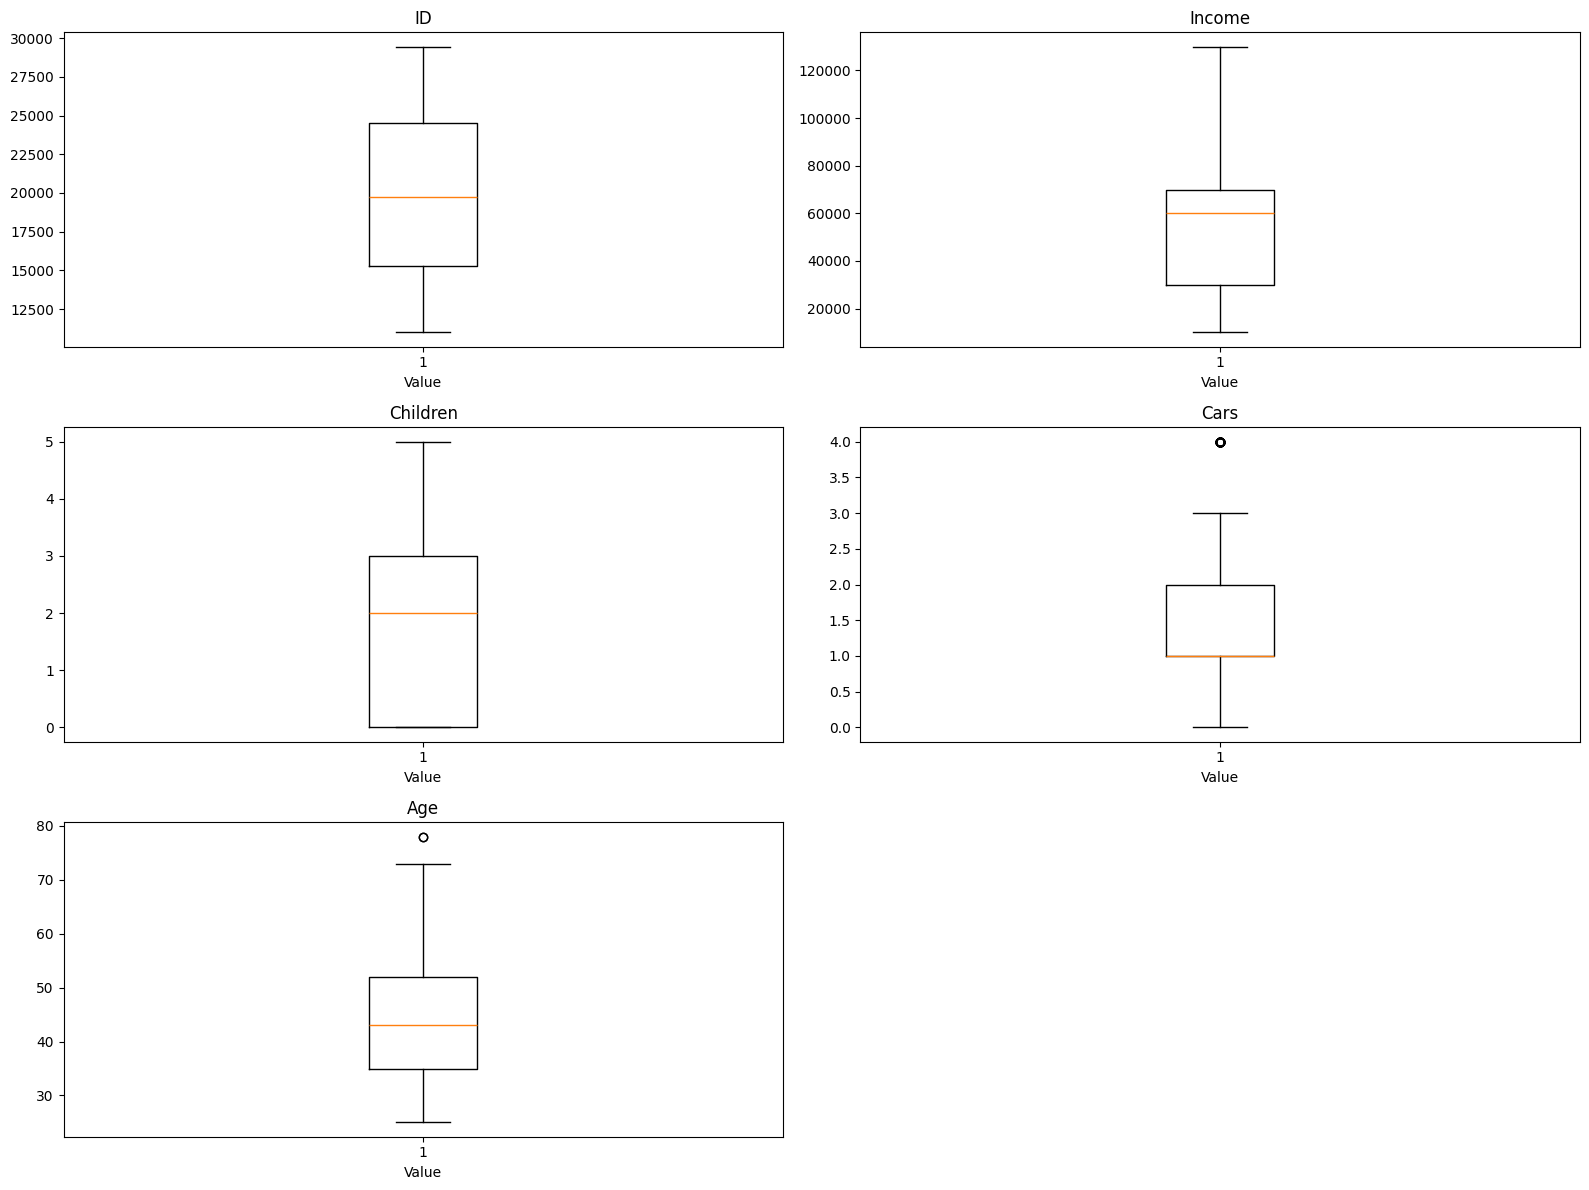

In [258]:
nc = dfb.select_dtypes(include = ['int64', 'float64'])
# Calculate the number of rows and columns for subplots
num_cols = len(nc.columns)
num_rows = math.ceil(num_cols / 2)  # Adjust the number of columns per row as needed

# Set the figure size
plt.figure(figsize=(16, 4 * num_rows))

# Iterate through each numerical column
for i, column in enumerate(nc.columns):
    plt.subplot(num_rows, 2, i+1)
    plt.boxplot(nc[column])
    plt.title(column)
    plt.xlabel('Value')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [259]:
dfc = dfb.copy()
dfc.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
5,13507,Married,Female,10000.0,2.0,Partial College,Manual,Yes,0.0,1-2 Miles,Europe,50.0,No


#### Label Encoding



In [260]:
dfc['Gender'] = dfc['Gender'].map({'Male':1, 'Female':0})
dfc['Home Owner'] = dfc['Home Owner'].map({'Yes':1, 'No':0})
dfc['Purchased Bike'] = dfc['Purchased Bike'].map({'Yes':1, 'No':0})
dfc['Marital Status'] = dfc['Marital Status'].map({'Married':1, 'Single':0})

In [261]:
dfc.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,1,0,40000.0,1.0,Bachelors,Skilled Manual,1,0.0,0-1 Miles,Europe,42.0,0
1,24107,1,1,30000.0,3.0,Partial College,Clerical,1,1.0,0-1 Miles,Europe,43.0,0
2,14177,1,1,80000.0,5.0,Partial College,Professional,0,2.0,2-5 Miles,Europe,60.0,0
4,25597,0,1,30000.0,0.0,Bachelors,Clerical,0,0.0,0-1 Miles,Europe,36.0,1
5,13507,1,0,10000.0,2.0,Partial College,Manual,1,0.0,1-2 Miles,Europe,50.0,0


In [262]:
# Define the custom rank mapping
education_mapping = {
    'Partial High School': 0,
    'High School': 1,
    'Partial College': 2,
    'Bachelors': 3,
    'Graduate Degree': 4
}


dfc['Education'] = dfc['Education'].map(education_mapping)

In [263]:
dfc.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,1,0,40000.0,1.0,3,Skilled Manual,1,0.0,0-1 Miles,Europe,42.0,0
1,24107,1,1,30000.0,3.0,2,Clerical,1,1.0,0-1 Miles,Europe,43.0,0
2,14177,1,1,80000.0,5.0,2,Professional,0,2.0,2-5 Miles,Europe,60.0,0
4,25597,0,1,30000.0,0.0,3,Clerical,0,0.0,0-1 Miles,Europe,36.0,1
5,13507,1,0,10000.0,2.0,2,Manual,1,0.0,1-2 Miles,Europe,50.0,0


#### One-hot Encoding

In [264]:
dfd = dfc.copy()

In [265]:
categorical_cols = ['Occupation', 'Region', 'Commute Distance']
dfd = pd.get_dummies(dfd, columns=categorical_cols, drop_first=True)
dfd = dfd.replace({True: 1, False: 0})

In [266]:
dfd.head()

,ID,Marital Status,Gender,Income,Children,Education,Home Owner,Cars,Age,Purchased Bike,Occupation_Management,Occupation_Manual,Occupation_Professional,Occupation_Skilled Manual,Region_North America,Region_Pacific,Commute Distance_1-2 Miles,Commute Distance_10+ Miles,Commute Distance_2-5 Miles,Commute Distance_5-10 Miles
0,12496,1,0,40000.0,1.0,3,1,0.0,42.0,0,0,0,0,1,0,0,0,0,0,0
1,24107,1,1,30000.0,3.0,2,1,1.0,43.0,0,0,0,0,0,0,0,0,0,0,0
2,14177,1,1,80000.0,5.0,2,0,2.0,60.0,0,0,0,1,0,0,0,0,0,1,0
4,25597,0,1,30000.0,0.0,3,0,0.0,36.0,1,0,0,0,0,0,0,0,0,0,0
5,13507,1,0,10000.0,2.0,2,1,0.0,50.0,0,0,1,0,0,0,0,1,0,0,0


# **Exploratory Data Analysis**

##### How does Gender relate to bike purchases?

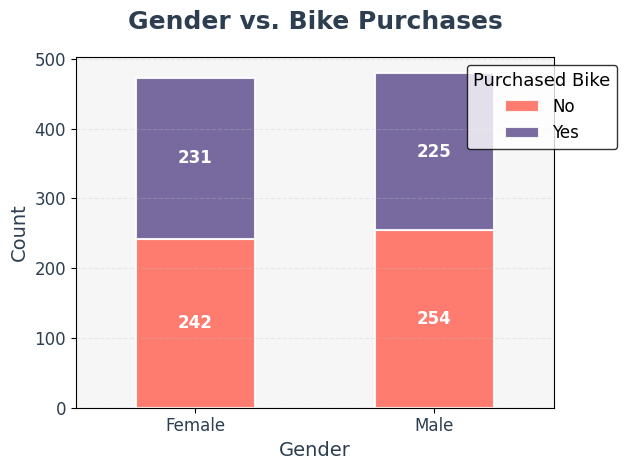

In [268]:
# Question 2: Gender vs. Bike Purchases
gender_bike = pd.crosstab(df['Gender'], df['Purchased Bike'])

# Create a beautiful stacked bar chart
# plt.figure(figsize=(12, 7))  # Larger figure for elegance
ax = gender_bike.plot(kind='bar', stacked=True,
                      color=['#FF6F61', '#6B5B95'],  # Elegant coral and purple
                      edgecolor='white', linewidth=1.5,  # White edges for separation
                      alpha=0.9)  # Transparency for depth

# Customize title and labels with elegant fonts
plt.title('Gender vs. Bike Purchases', fontsize=18, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel('Gender', fontsize=14, color='#2C3E50')
plt.ylabel('Count', fontsize=14, color='#2C3E50')

# Add data labels with a stylish touch
for i in range(len(gender_bike)):
    for j in range(len(gender_bike.columns)):
        count = gender_bike.iloc[i, j]
        total = gender_bike.iloc[i].sum()
        y_position = gender_bike.iloc[i].cumsum()[j] - count/2  # Center label in stack
        if count > 0:  # Only add label if count is non-zero
            plt.text(i, y_position, f'{count}', ha='center', va='center',
                     fontsize=12, fontweight='bold', color='white')

# Customize the legend
plt.legend(title='Purchased Bike', fontsize=12, title_fontsize=13, loc='upper right',
           bbox_to_anchor=(1.15, 1), frameon=True, edgecolor='black')

# Add a subtle grid and background
plt.grid(axis='y', linestyle='--', alpha=0.3, color='#BDC3C7')
plt.gca().set_facecolor('#F5F6F5')  # Light background for contrast
plt.gcf().set_facecolor('#FFFFFF')  # White figure background

# Adjust ticks and layout
plt.xticks(rotation=0, fontsize=12, color='#2C3E50')
plt.yticks(fontsize=12, color='#2C3E50')
plt.tight_layout()

# Save and display
# plt.savefig('gender_bike_purchases.png', dpi=300, bbox_inches='tight')
plt.show()

##### How does occupation influence the number of cars owned?

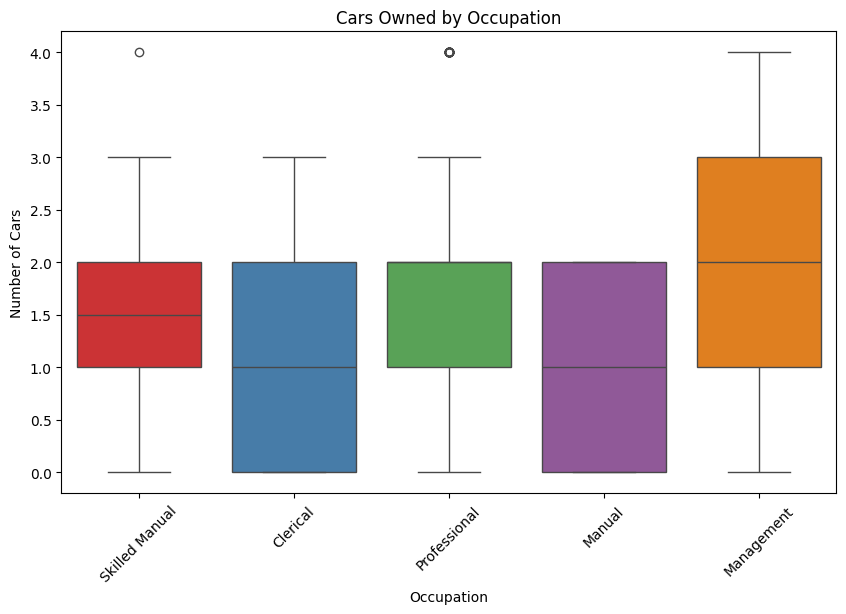

In [270]:
# Question 6: Cars Owned by Occupation
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation', y='Cars', data=df, palette='Set1')
plt.title('Cars Owned by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.show()

##### Does home ownership affect bike purchases?

<Figure size 800x500 with 0 Axes>

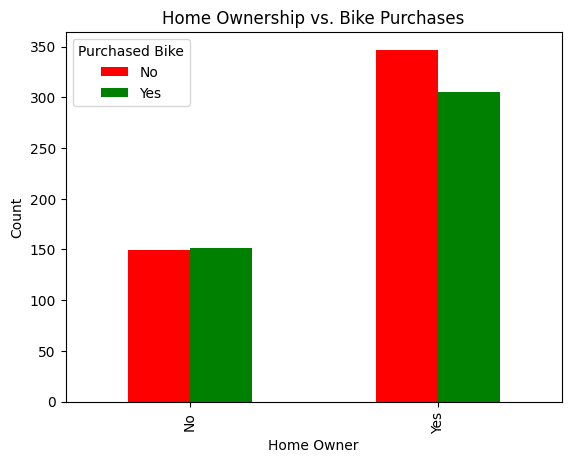

In [273]:
# Question 9: Home Ownership vs. Bike Purchases
home_bike = pd.crosstab(df['Home Owner'], df['Purchased Bike'])
plt.figure(figsize=(8, 5))
home_bike.plot(kind='bar', color=['red', 'green'])
plt.title('Home Ownership vs. Bike Purchases')
plt.xlabel('Home Owner')
plt.ylabel('Count')
plt.legend(title='Purchased Bike')
plt.show()

##### How does region affect income and bike purchases?

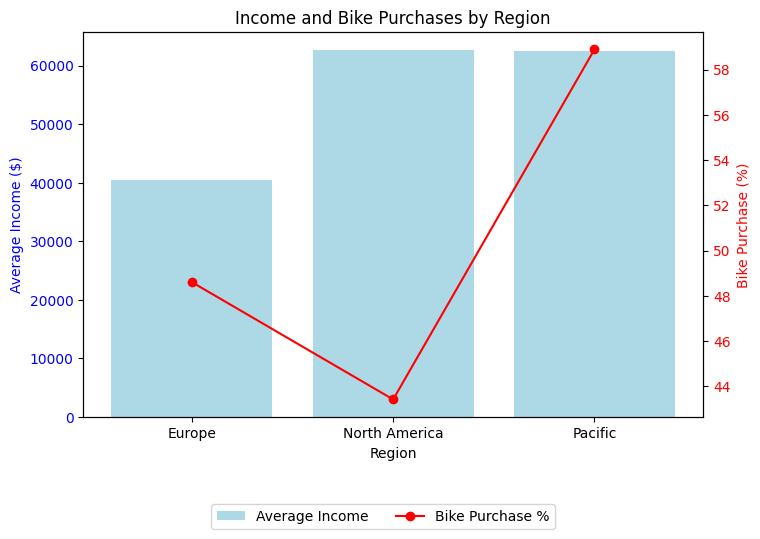

In [274]:
# Question 10: Income and Bike Purchases by Region
income_region = df.groupby('Region')['Income'].mean()
bike_region = df.groupby('Region')['Purchased Bike'].apply(lambda x: (x == 'Yes').mean() * 100)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(income_region.index, income_region.values, color='lightblue', label='Average Income')
ax1.set_xlabel('Region')
ax1.set_ylabel('Average Income ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(bike_region.index, bike_region.values, color='red', marker='o', label='Bike Purchase %')
ax2.set_ylabel('Bike Purchase (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Income and Bike Purchases by Region')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.show()

##### What is the relationship between age and income?

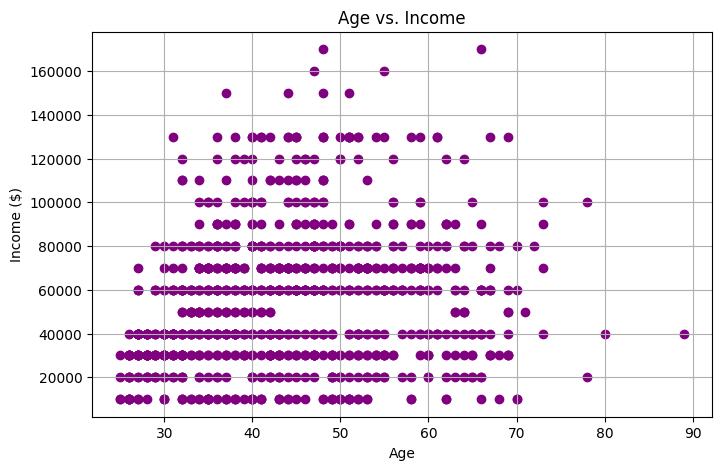

In [275]:
# Question 11: Age vs. Income
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Income'], color='purple')
plt.title('Age vs. Income')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.grid(True)
plt.show()

##### How does marital status and gender together affect bike purchases?

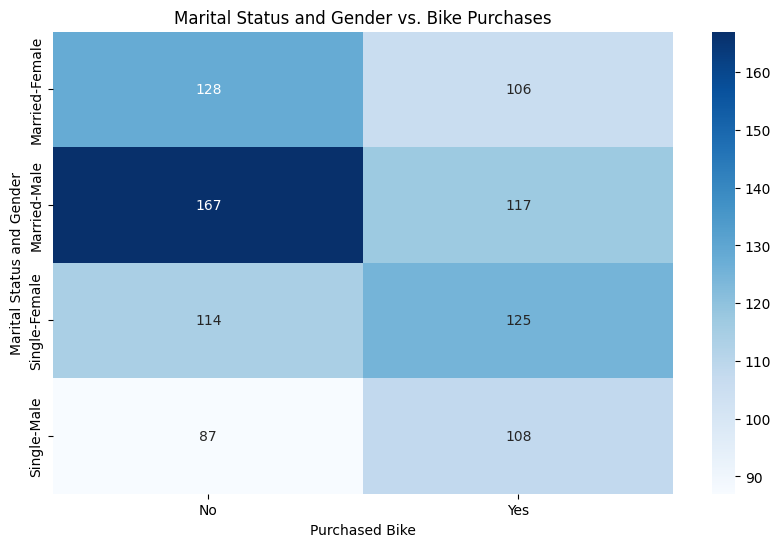

In [276]:
# Question 12: Marital Status and Gender vs. Bike Purchases
marital_gender_bike = pd.crosstab([df['Marital Status'], df['Gender']], df['Purchased Bike'])
plt.figure(figsize=(10, 6))
sns.heatmap(marital_gender_bike, annot=True, cmap='Blues', fmt='d')
plt.title('Marital Status and Gender vs. Bike Purchases')
plt.xlabel('Purchased Bike')
plt.ylabel('Marital Status and Gender')
plt.show()

##### What is the distribution of Marital Status?

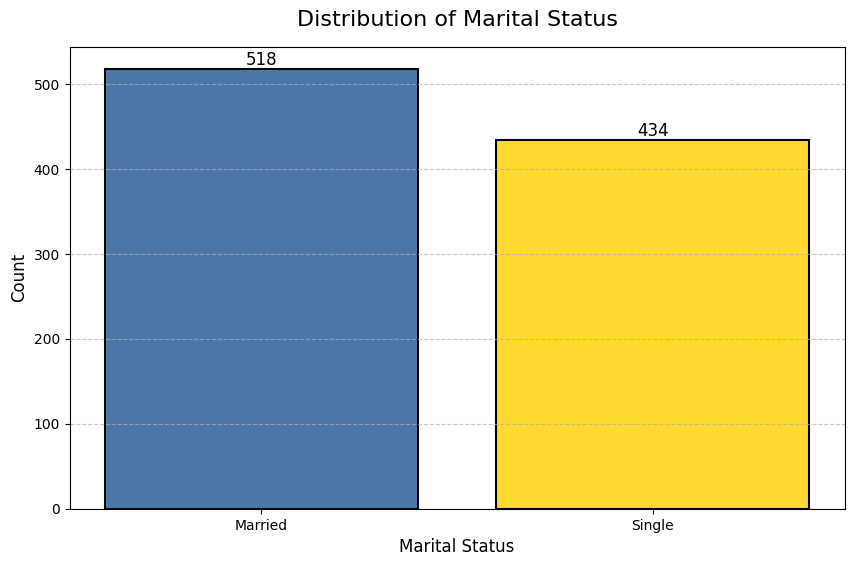

In [277]:
marital_counts = df['Marital Status'].value_counts()
plt.figure(figsize=(10, 6))
bars = plt.bar(marital_counts.index, marital_counts.values, color=['#4C78A8', '#FFD92F'], edgecolor='black', linewidth=1.5)
plt.title('Distribution of Marital Status', fontsize=16, pad=15)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### What is the average income by region?

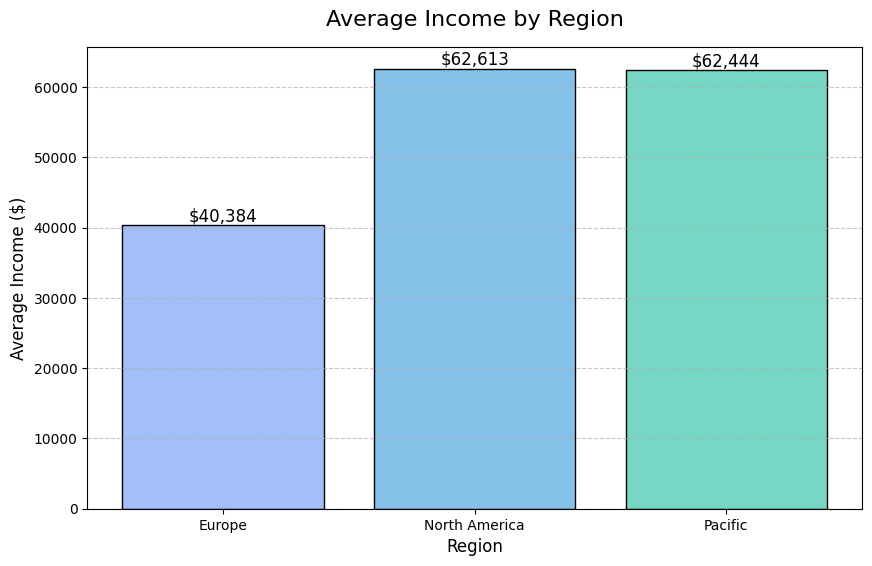

In [279]:
income_region = df.groupby('Region')['Income'].mean()
plt.figure(figsize=(10, 6))
bars = plt.bar(income_region.index, income_region.values, color=['#A3BFFA', '#85C1E9', '#76D7C4'], edgecolor='black')
plt.title('Average Income by Region', fontsize=16, pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Income ($)', fontsize=12)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${int(bar.get_height()):,}', ha='center', va='bottom', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### How does the number of children affect bike purchases?

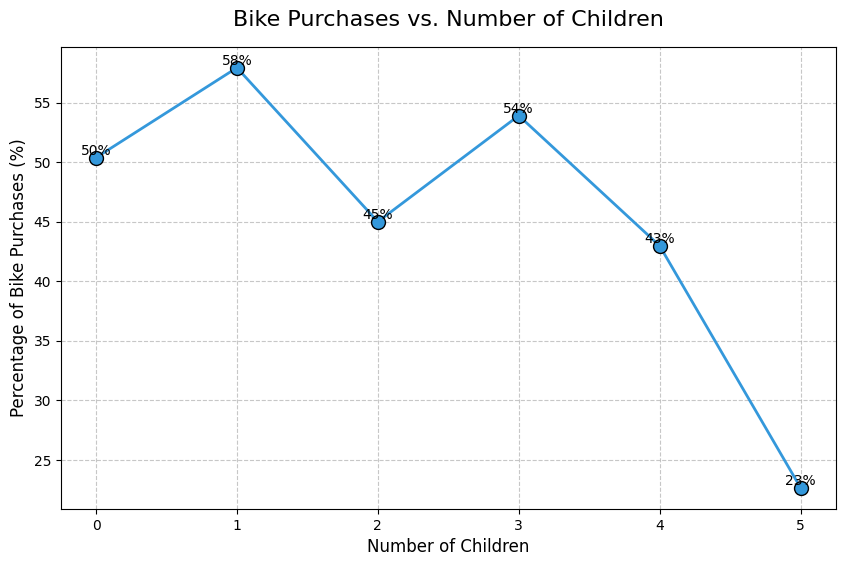

In [280]:
children_bike = df.groupby('Children')['Purchased Bike'].apply(lambda x: (x == 'Yes').mean() * 100)
plt.figure(figsize=(10, 6))
plt.plot(children_bike.index, children_bike.values, marker='o', color='#3498DB', linewidth=2, markersize=10, markeredgecolor='black')
plt.title('Bike Purchases vs. Number of Children', fontsize=16, pad=15)
plt.xlabel('Number of Children', fontsize=12)
plt.ylabel('Percentage of Bike Purchases (%)', fontsize=12)
for x, y in zip(children_bike.index, children_bike.values):
    plt.text(x, y, f'{y:.0f}%', ha='center', va='bottom', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### What is the relationship between education and income?

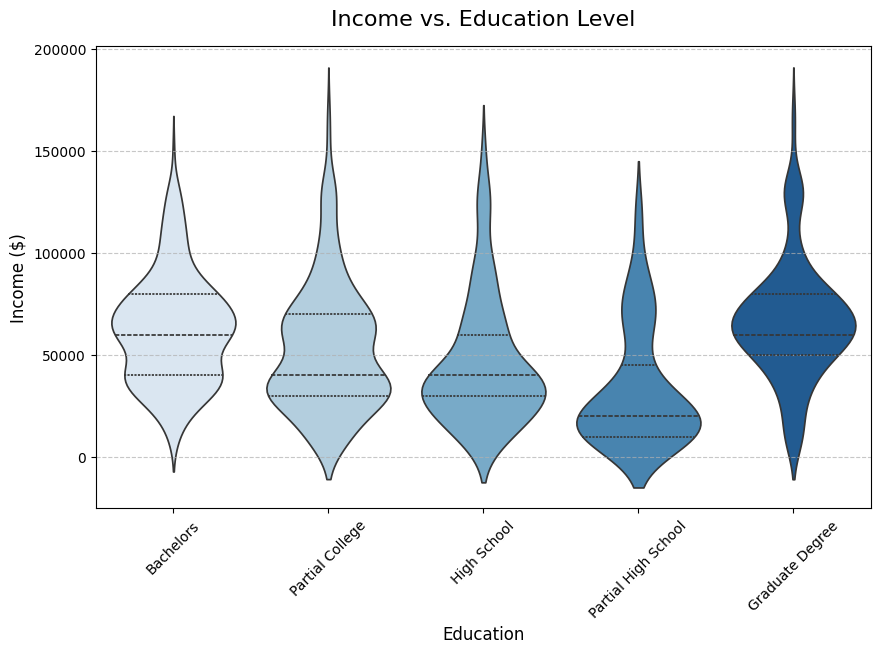

In [281]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Education', y='Income', data=df, palette='Blues', inner='quartile')
plt.title('Income vs. Education Level', fontsize=16, pad=15)
plt.xlabel('Education', fontsize=12)
plt.ylabel('Income ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### What is the age distribution of people who purchased bikes?

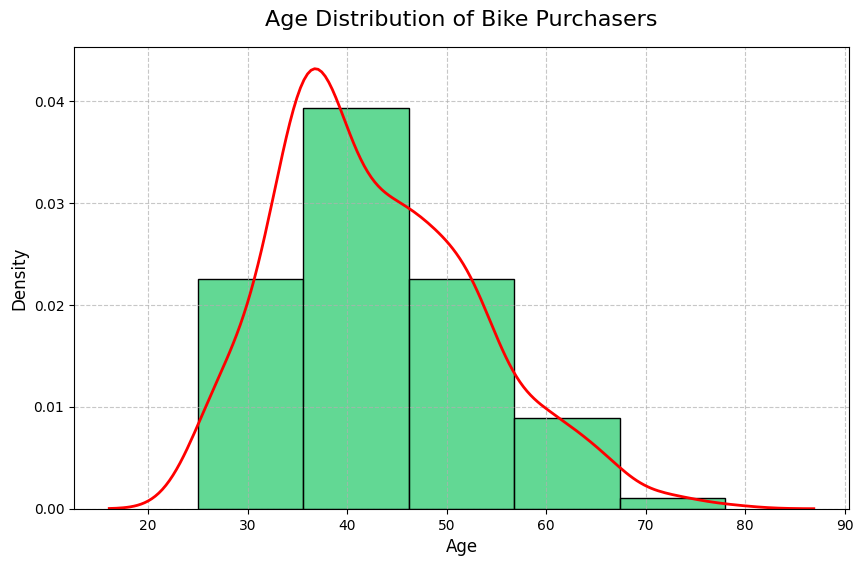

In [283]:
bike_ages = df[df['Purchased Bike'] == 'Yes']['Age']
plt.figure(figsize=(10, 6))
sns.histplot(bike_ages, bins=5, color='#2ECC71', edgecolor='black', stat='density')
sns.kdeplot(bike_ages, color='red', linewidth=2)
plt.title('Age Distribution of Bike Purchasers', fontsize=16, pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### How does commute distance relate to bike purchases?

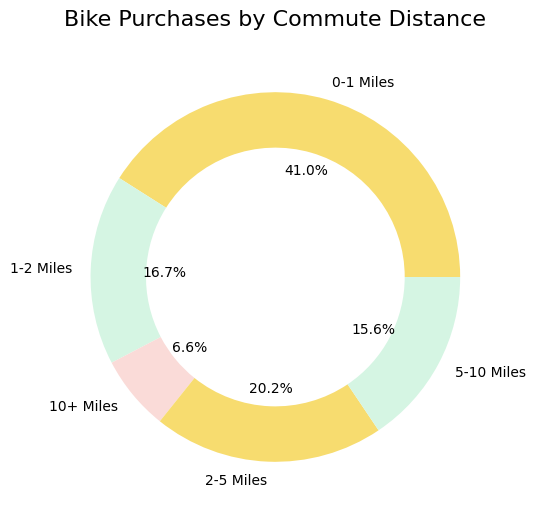

In [284]:
commute_bike = df.groupby('Commute Distance')['Purchased Bike'].apply(lambda x: (x == 'Yes').sum())
plt.figure(figsize=(8, 6))
plt.pie(commute_bike, labels=commute_bike.index, autopct='%1.1f%%', colors=['#F7DC6F', '#D5F5E3', '#FADBD8'], wedgeprops=dict(width=0.3))
plt.title('Bike Purchases by Commute Distance', fontsize=16, pad=15)
plt.show()

##### What is the trend of bike purchases by age group?

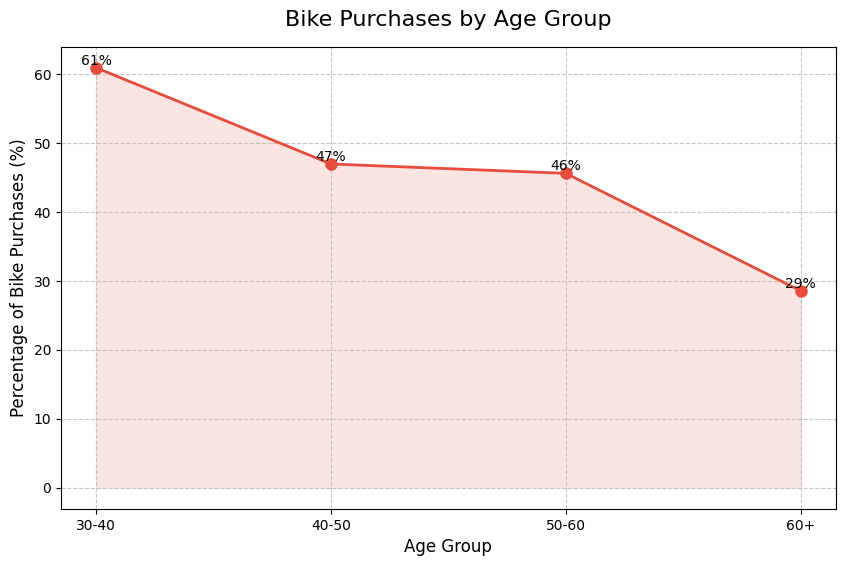

In [285]:
df['Age Group'] = pd.cut(df['Age'], bins=[30, 40, 50, 60, 90], labels=['30-40', '40-50', '50-60', '60+'])
age_bike = df.groupby('Age Group')['Purchased Bike'].apply(lambda x: (x == 'Yes').mean() * 100)
plt.figure(figsize=(10, 6))
plt.fill_between(age_bike.index, age_bike.values, color='#FADBD8', alpha=0.7)
plt.plot(age_bike.index, age_bike.values, color='#E74C3C', linewidth=2, marker='o', markersize=8)
plt.title('Bike Purchases by Age Group', fontsize=16, pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Percentage of Bike Purchases (%)', fontsize=12)
for x, y in age_bike.items():
    plt.text(x, y, f'{y:.0f}%', ha='center', va='bottom', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### How does the number of cars relate to income levels?

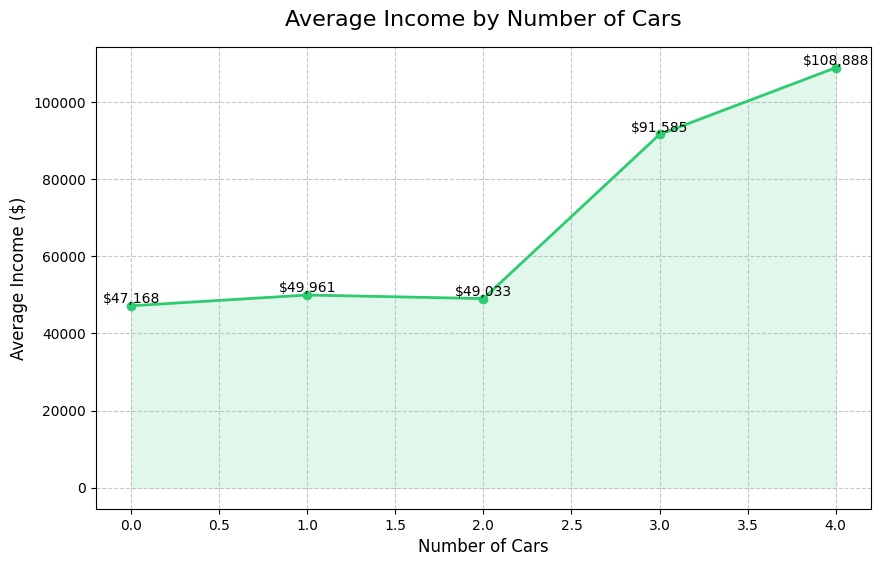

In [286]:
cars_income = df.groupby('Cars')['Income'].mean()
plt.figure(figsize=(10, 6))
plt.fill_between(cars_income.index, cars_income.values, color='#D5F5E3', alpha=0.7)
plt.plot(cars_income.index, cars_income.values, color='#2ECC71', linewidth=2, marker='o')
plt.title('Average Income by Number of Cars', fontsize=16, pad=15)
plt.xlabel('Number of Cars', fontsize=12)
plt.ylabel('Average Income ($)', fontsize=12)
for x, y in cars_income.items():
    plt.text(x, y, f'${int(y):,}', ha='center', va='bottom', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

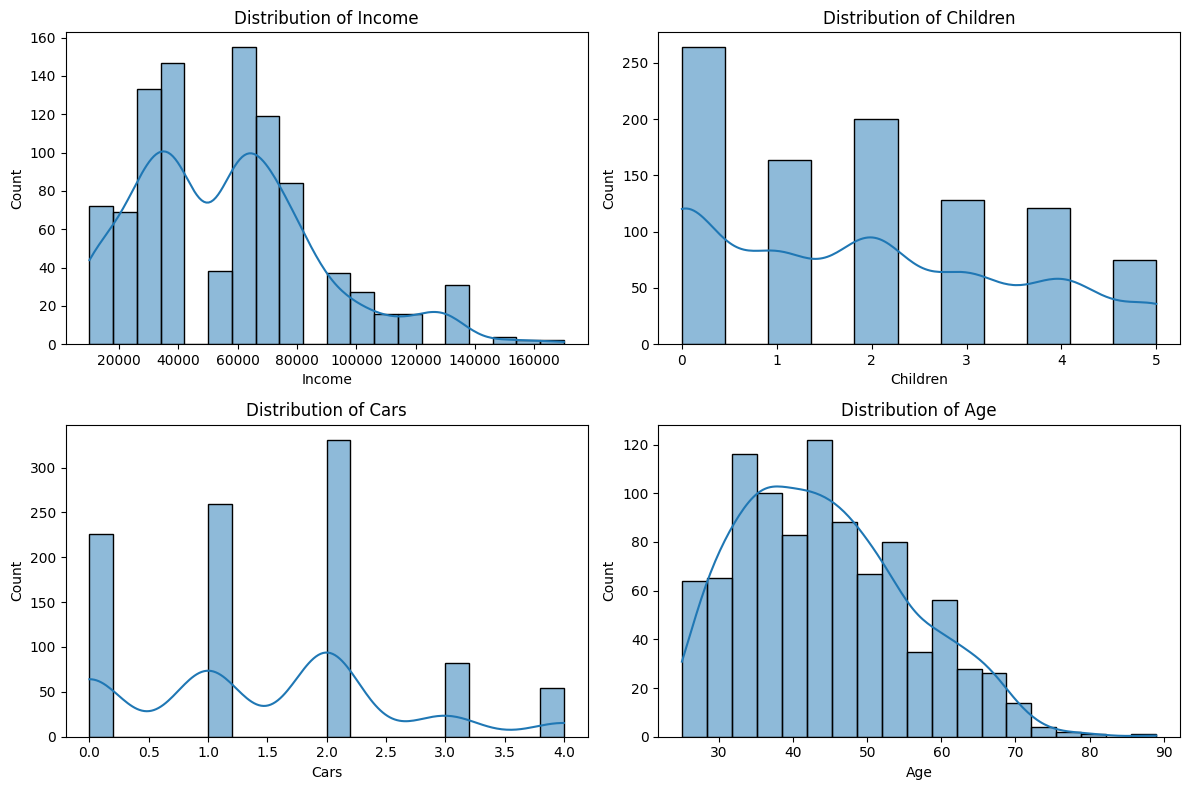

In [287]:
# 3. Visualizations
# Histogram for numerical variables
numerical_cols = ['Income', 'Children', 'Cars', 'Age']
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

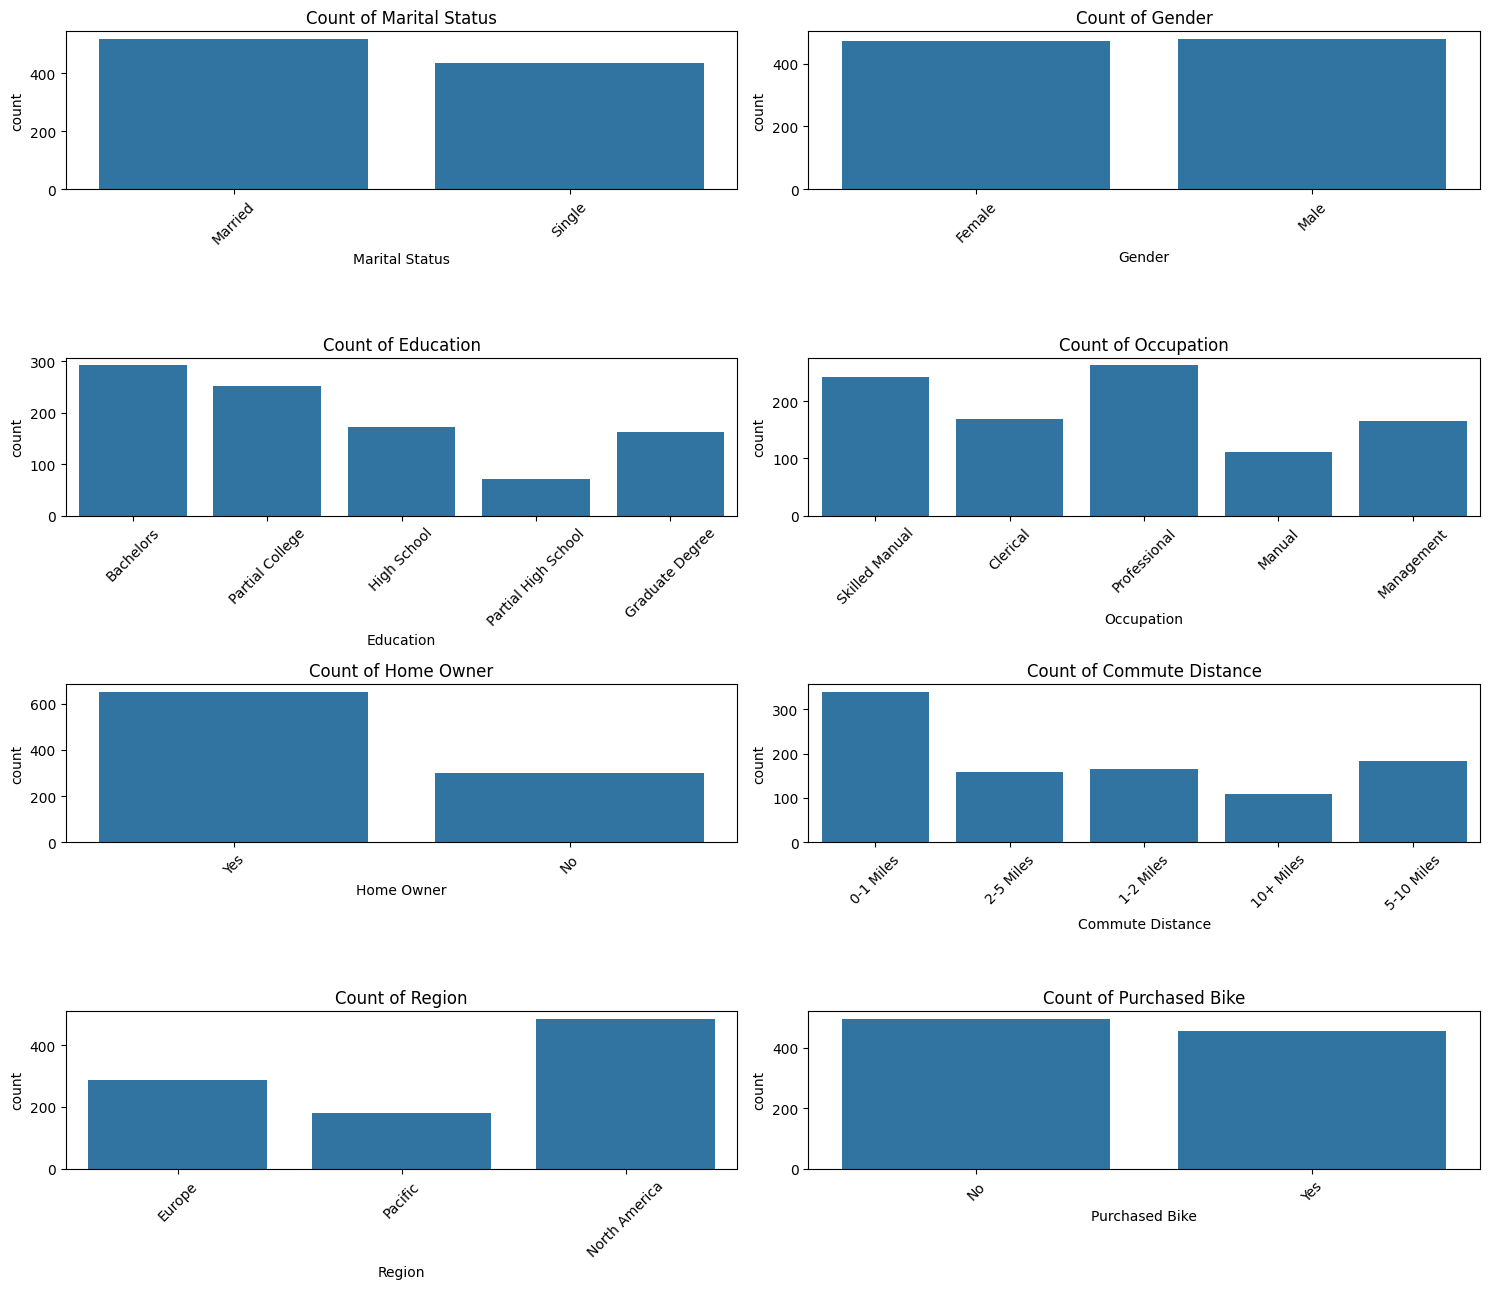

In [288]:
# Bar plots for categorical variables
categorical_cols = ['Marital Status', 'Gender', 'Education', 'Occupation',
                    'Home Owner', 'Commute Distance', 'Region', 'Purchased Bike']
plt.figure(figsize=(15, 13))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 2, i)
    sns.countplot(data=df, x=col)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

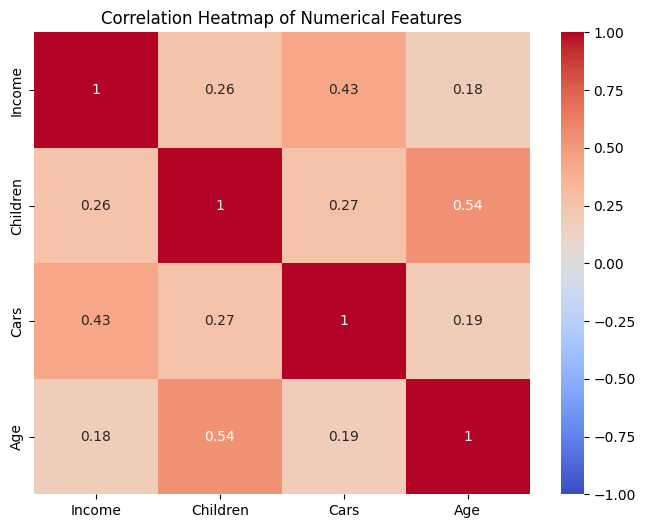

In [289]:
# 4. Correlation Heatmap (for numerical variables)
plt.figure(figsize=(8, 6))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

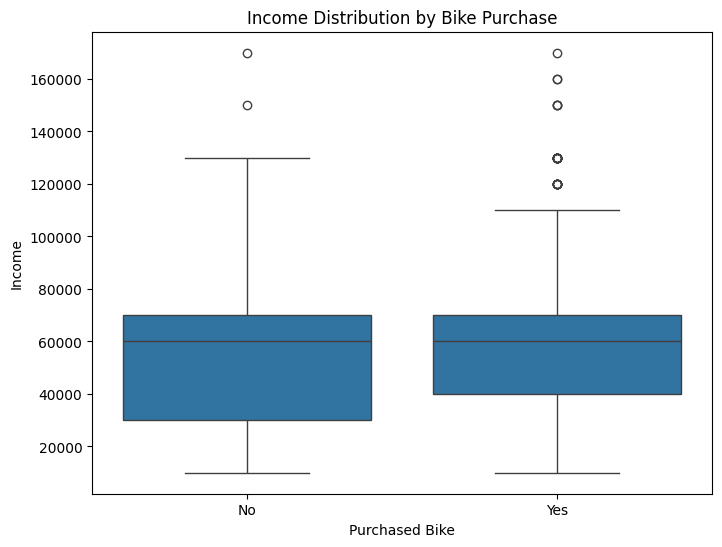

In [290]:
# Box plot: Income vs Purchased Bike
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Purchased Bike', y='Income')
plt.title('Income Distribution by Bike Purchase')
plt.show()

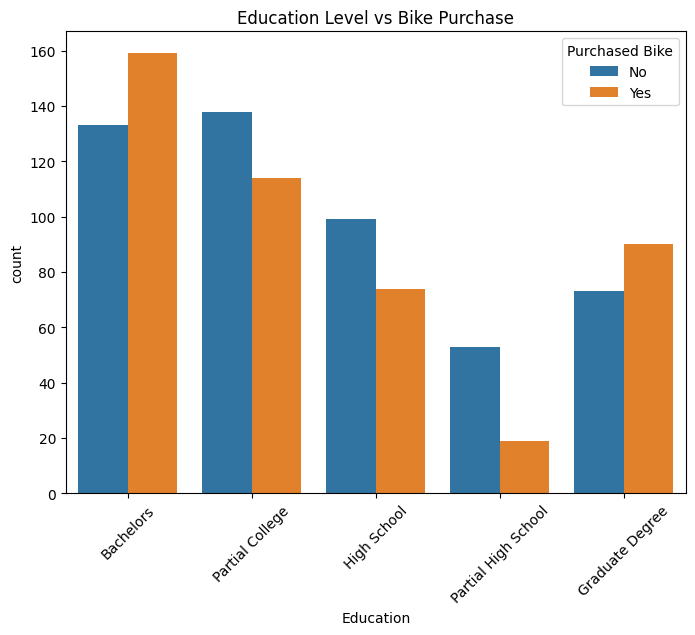

In [291]:
# Count plot: Education vs Purchased Bike
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Education', hue='Purchased Bike')
plt.title('Education Level vs Bike Purchase')
plt.xticks(rotation=45)
plt.show()

In [292]:
# 6. Trends, Patterns, and Potential Biases
print("\nEDA Observations:")
print("1. Distribution Analysis:")
for col in numerical_cols:
    skewness = stats.skew(df[col].dropna())
    print(f"- {col}: Skewness = {skewness:.2f} (positive skew indicates longer right tail)")

print("\n2. Categorical Patterns:")
print("- Check bar plots for imbalances (e.g., Gender, Region) that might indicate sampling bias.")
print("- Purchased Bike distribution: Check if 'Yes'/'No' is balanced.")

print("\n3. Correlations:")
for i in range(len(numerical_cols)):
    for j in range(i+1, len(numerical_cols)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.5:
            print(f"- Strong correlation between {numerical_cols[i]} and {numerical_cols[j]}: {corr:.2f}")

print("\n4. Potential Biases:")
print("- Missing Gender values (e.g., NaN in row 3) could bias gender-related insights.")
print("- Regional distribution might overrepresent Europe, potentially skewing results.")
print("- Income outliers (visible in box plot) could affect regression models.")


EDA Observations:
1. Distribution Analysis:
- Income: Skewness = 0.72 (positive skew indicates longer right tail)
- Children: Skewness = 0.40 (positive skew indicates longer right tail)
- Cars: Skewness = 0.41 (positive skew indicates longer right tail)
- Age: Skewness = 0.50 (positive skew indicates longer right tail)

2. Categorical Patterns:
- Check bar plots for imbalances (e.g., Gender, Region) that might indicate sampling bias.
- Purchased Bike distribution: Check if 'Yes'/'No' is balanced.

3. Correlations:
- Strong correlation between Children and Age: 0.54

4. Potential Biases:
- Missing Gender values (e.g., NaN in row 3) could bias gender-related insights.
- Regional distribution might overrepresent Europe, potentially skewing results.
- Income outliers (visible in box plot) could affect regression models.


# **Model Development & Evaluation**

### **Linear Regression**

In [293]:
X = dfd.drop(columns=['ID', 'Income'])  # All preprocessed variables except 'Income'
y = dfd['Income']  # Target variable is 'Income'

In [294]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [295]:
# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [296]:
# Make predictions
y_pred = lr_model.predict(X_test)

In [297]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [298]:
# Print evaluation metrics
print("Linear Regression Performance:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Linear Regression Performance:
Mean Squared Error (MSE): 328959539.71
R-squared (R2): 0.63


In [299]:
# Display coefficients
coefficients = pd.DataFrame(lr_model.coef_, X.columns, columns=['Coefficient'])
print("\nModel Coefficients:")
print(coefficients)


Model Coefficients:
                              Coefficient
Marital Status                -315.601727
Gender                       -2193.324903
Children                       984.804744
Education                     2496.009724
Home Owner                    -582.618286
Cars                          5491.815800
Age                           -372.760418
Purchased Bike                2192.613832
Occupation_Management        51513.679427
Occupation_Manual           -17802.979087
Occupation_Professional      39727.661271
Occupation_Skilled Manual    21564.174201
Region_North America         -6431.939981
Region_Pacific               -6070.140359
Commute Distance_1-2 Miles    1568.096824
Commute Distance_10+ Miles   -4117.262246
Commute Distance_2-5 Miles     533.359732
Commute Distance_5-10 Miles  -2181.717402


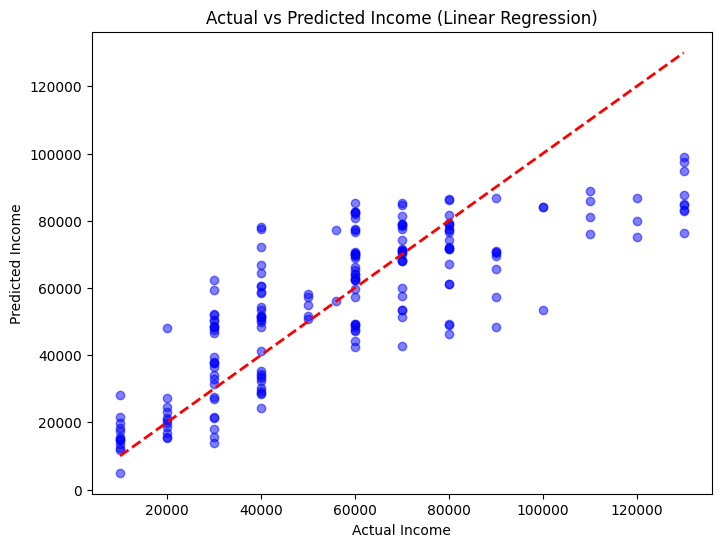

In [300]:
# Visualize Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Income')
plt.ylabel('Predicted Income')
plt.title('Actual vs Predicted Income (Linear Regression)')
plt.show()

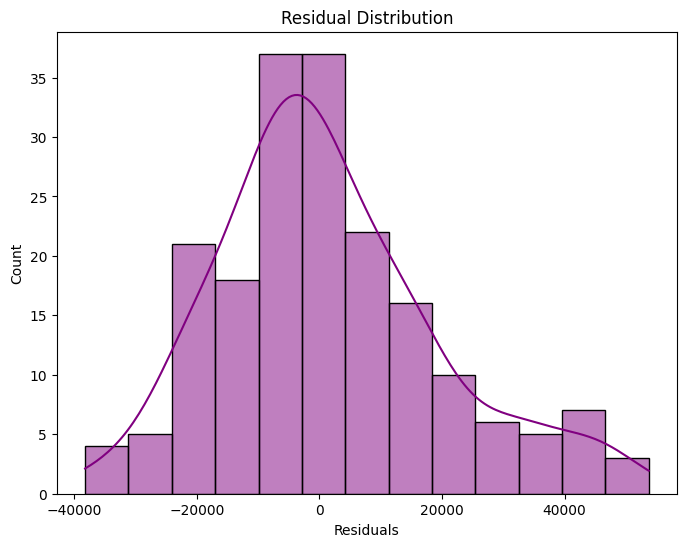

In [301]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel('Residuals')
plt.title('Residual Distribution')
plt.show()

### **Classification**

In [302]:
X = dfd.drop(['ID'], axis=1)  # Features for classification
y_class = df['Purchased Bike']

In [303]:
X_train, X_test, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [304]:
print(X_train.shape)
print(X_test.shape)
print(y_train_class.shape)
print(y_test_class.shape)

(761, 19)
(191, 19)
(761,)
(191,)


In [305]:
# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)  # Increased max_iter for convergence
log_model.fit(X_train, y_train_class)

LogisticRegression(max_iter=1000, random_state=42)

In [306]:
# Make predictions
log_pred = log_model.predict(X_test)

In [307]:
# Evaluate Logistic Regression
log_accuracy = accuracy_score(y_test_class, log_pred)
print("Logistic Regression Results (Predicting Purchased Bike):")
print(f"Accuracy: {log_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, log_pred))

Logistic Regression Results (Predicting Purchased Bike):
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        93
         Yes       1.00      1.00      1.00        98

    accuracy                           1.00       191
   macro avg       1.00      1.00      1.00       191
weighted avg       1.00      1.00      1.00       191



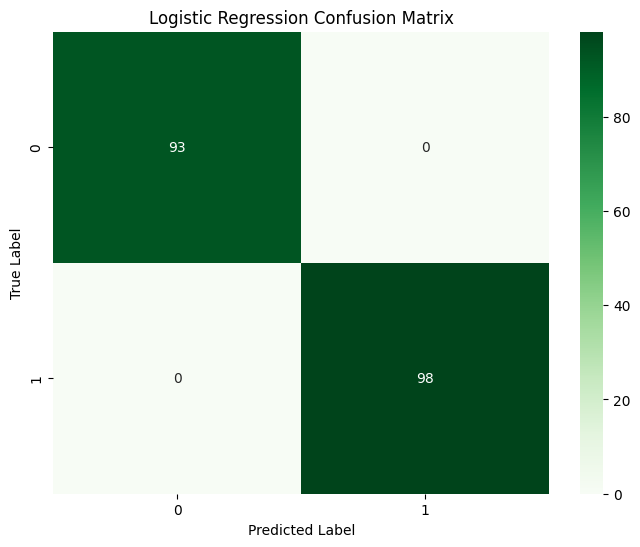

In [308]:
# Confusion Matrix Visualization for Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_class, log_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

#### **Decision Tree**

In [309]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train_class)

DecisionTreeClassifier(random_state=42)

In [310]:
# Make predictions
dt_pred = dt_model.predict(X_test)

In [311]:
# Evaluate Decision Tree
dt_accuracy = accuracy_score(y_test_class, dt_pred)
print("\nDecision Tree Classifier Results (Predicting Purchased Bike):")
print(f"Accuracy: {dt_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, dt_pred))


Decision Tree Classifier Results (Predicting Purchased Bike):
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        93
         Yes       1.00      1.00      1.00        98

    accuracy                           1.00       191
   macro avg       1.00      1.00      1.00       191
weighted avg       1.00      1.00      1.00       191



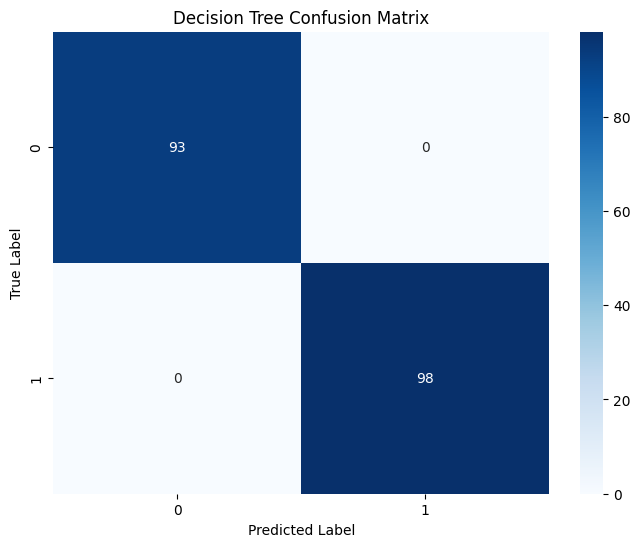

In [312]:
# Confusion Matrix Visualization for Decision Tree
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_class, dt_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## **Feature Selection**

#### **Regression**

In [313]:
Xl = dfd.drop(columns=['ID', 'Income'])  # All preprocessed variables except 'Income'
yl = dfd['Income']  # Target variable is 'Income'

In [314]:
# Perform feature selection using SelectKBest with f_regression
# Select the top 5 features (you can adjust k as needed)
k = 12  # Number of top features to select
selector = SelectKBest(score_func=f_regression, k=k)
X_selected = selector.fit_transform(Xl, yl)


In [315]:
# Get the selected feature names
selected_mask = selector.get_support()  # Boolean mask of selected features
selected_features = Xl.columns[selected_mask].tolist()
print("Selected Features:", selected_features)

Selected Features: ['Marital Status', 'Children', 'Education', 'Cars', 'Age', 'Occupation_Management', 'Occupation_Manual', 'Occupation_Professional', 'Region_North America', 'Region_Pacific', 'Commute Distance_10+ Miles', 'Commute Distance_2-5 Miles']


In [316]:
# Create a new DataFrame with only the selected features
Xl = Xl[selected_features]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(Xl, yl, test_size=0.2, random_state=42)

In [317]:
# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [318]:
# Make predictions
y_pred = lr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [319]:
# Print evaluation metrics
print("\nLinear Regression Performance (with Feature Selection):")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Linear Regression Performance (with Feature Selection):
Mean Squared Error (MSE): 360837285.77
R-squared (R2): 0.60


In [320]:
# Display coefficients
coefficients = pd.DataFrame(lr_model.coef_, Xl.columns, columns=['Coefficient'])
print("\nModel Coefficients:")
print(coefficients)


Model Coefficients:
                             Coefficient
Marital Status               -363.181440
Children                     1334.097390
Education                    3562.255737
Cars                         6318.715188
Age                          -434.140389
Occupation_Management       35633.251506
Occupation_Manual          -24774.643744
Occupation_Professional     24817.544555
Region_North America         1339.264715
Region_Pacific               -817.380399
Commute Distance_10+ Miles  -3258.956599
Commute Distance_2-5 Miles   1264.472263


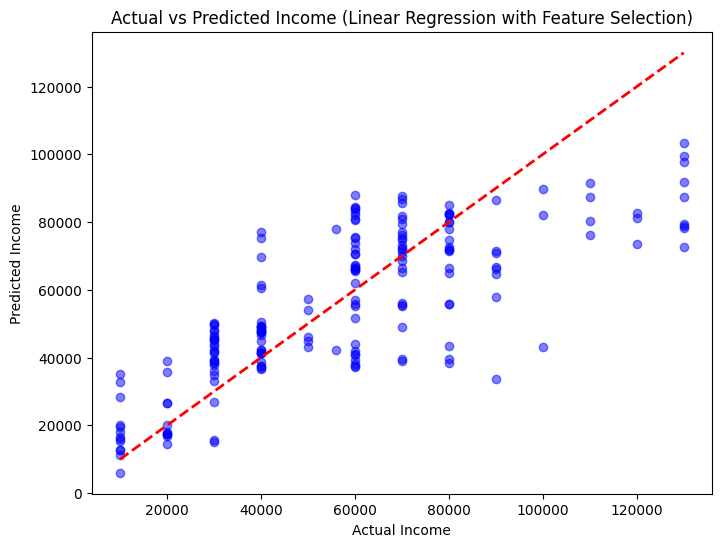

In [321]:
# Visualize Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Income')
plt.ylabel('Predicted Income')
plt.title('Actual vs Predicted Income (Linear Regression with Feature Selection)')
plt.show()

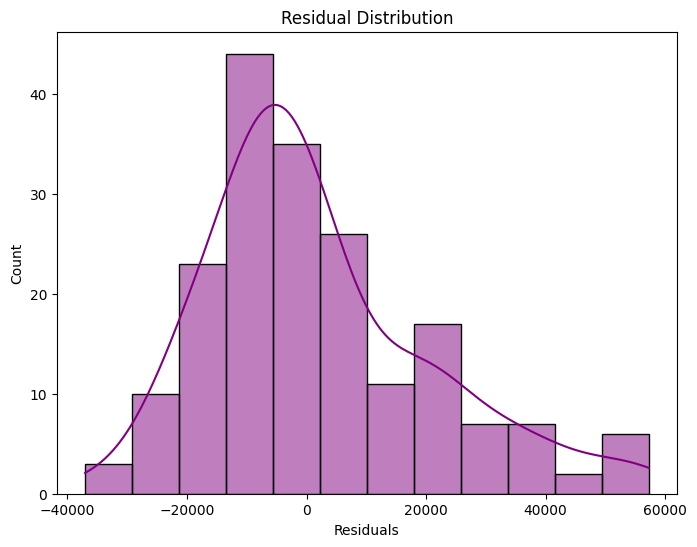

In [322]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel('Residuals')
plt.title('Residual Distribution')
plt.show()

#### **Classification**

In [323]:
# Apply SelectKBest with chi-squared test to select top k features
k = 10  # Select top 10 features (you can adjust this number)
selector = SelectKBest(score_func=chi2, k=k)
X_selected = selector.fit_transform(X, y_class)

In [324]:
# Get selected feature names
selected_features = X.columns[selector.get_support()].tolist()
print("Selected Features:", selected_features)

Selected Features: ['Income', 'Children', 'Education', 'Cars', 'Age', 'Purchased Bike', 'Region_Pacific', 'Commute Distance_10+ Miles', 'Commute Distance_2-5 Miles', 'Commute Distance_5-10 Miles']


In [325]:
# Update X with selected features
X = pd.DataFrame(X_selected, columns=selected_features)

In [326]:
X_train, X_test, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [327]:
# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)  # Increased max_iter for convergence
log_model.fit(X_train, y_train_class)

LogisticRegression(max_iter=1000, random_state=42)

In [328]:
# Make predictions
log_pred = log_model.predict(X_test)

In [329]:
log_prob = log_model.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve

In [330]:
# Evaluate Logistic Regression
log_accuracy = accuracy_score(y_test_class, log_pred)
print("Logistic Regression Results (Predicting Purchased Bike):")
print(f"Accuracy: {log_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, log_pred))

Logistic Regression Results (Predicting Purchased Bike):
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        93
         Yes       1.00      1.00      1.00        98

    accuracy                           1.00       191
   macro avg       1.00      1.00      1.00       191
weighted avg       1.00      1.00      1.00       191



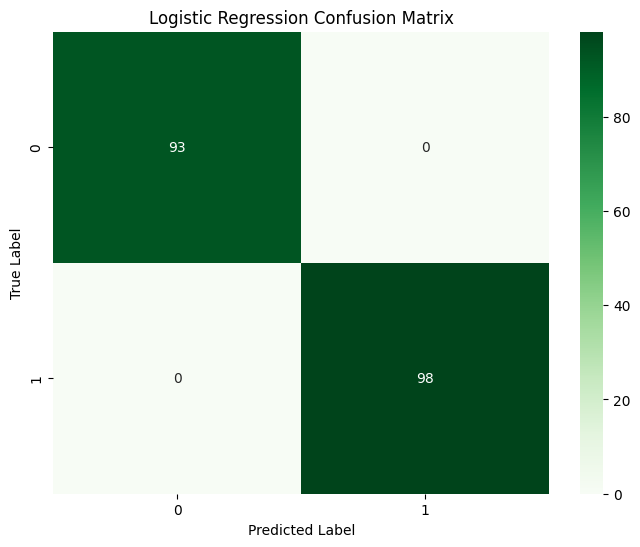

In [331]:
# Confusion Matrix Visualization for Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_class, log_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

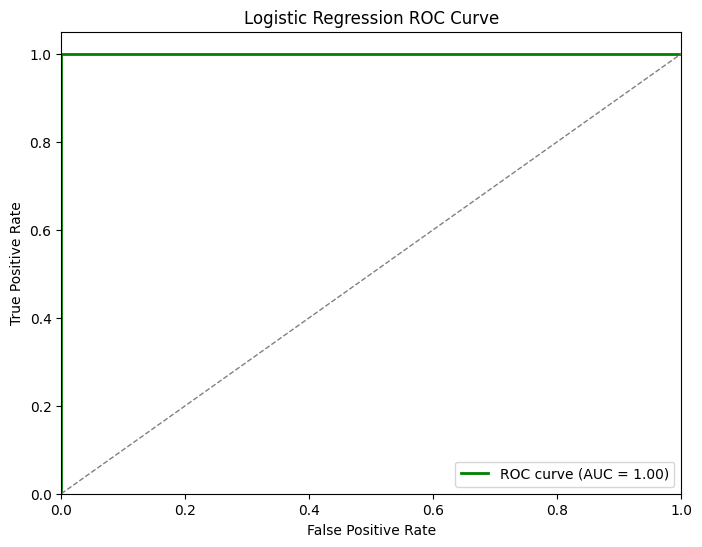

In [332]:
# ROC Curve for Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test_class.map({'No': 0, 'Yes': 1}), log_prob)
roc_auc_log = auc(fpr_log, tpr_log)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_log:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [333]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train_class)

DecisionTreeClassifier(random_state=42)

In [334]:
# Make predictions
dt_pred = dt_model.predict(X_test)

In [335]:
dt_prob = dt_model.predict_proba(X_test)[:, 1]

In [336]:
# Evaluate Decision Tree
dt_accuracy = accuracy_score(y_test_class, dt_pred)
print("\nDecision Tree Classifier Results (Predicting Purchased Bike):")
print(f"Accuracy: {dt_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, dt_pred))


Decision Tree Classifier Results (Predicting Purchased Bike):
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        93
         Yes       1.00      1.00      1.00        98

    accuracy                           1.00       191
   macro avg       1.00      1.00      1.00       191
weighted avg       1.00      1.00      1.00       191



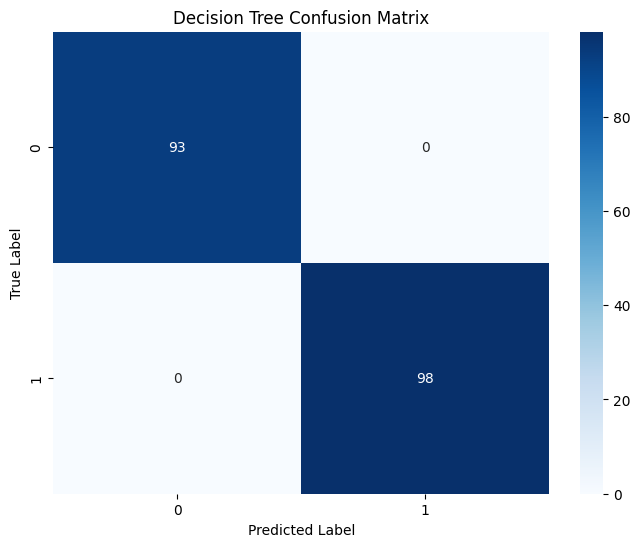

In [337]:
# Confusion Matrix Visualization for Decision Tree
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_class, dt_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

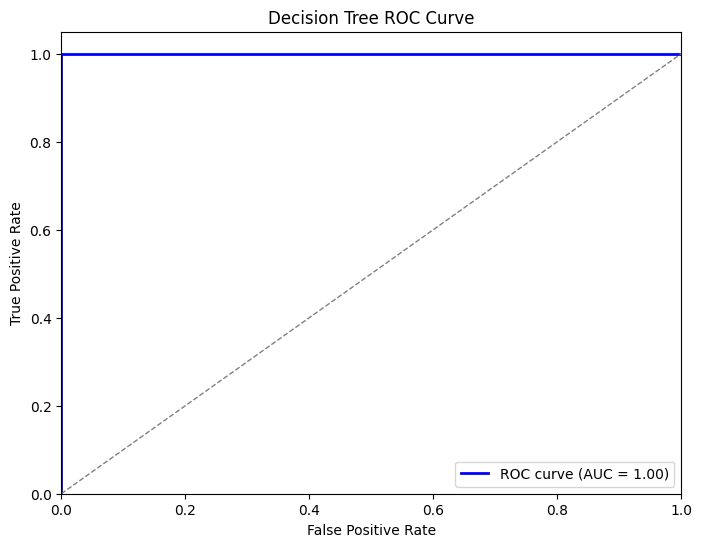

In [338]:
# ROC Curve for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test_class.map({'No': 0, 'Yes': 1}), dt_prob)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend(loc="lower right")
plt.show()

## **Clustering** - For Hidden Patterns

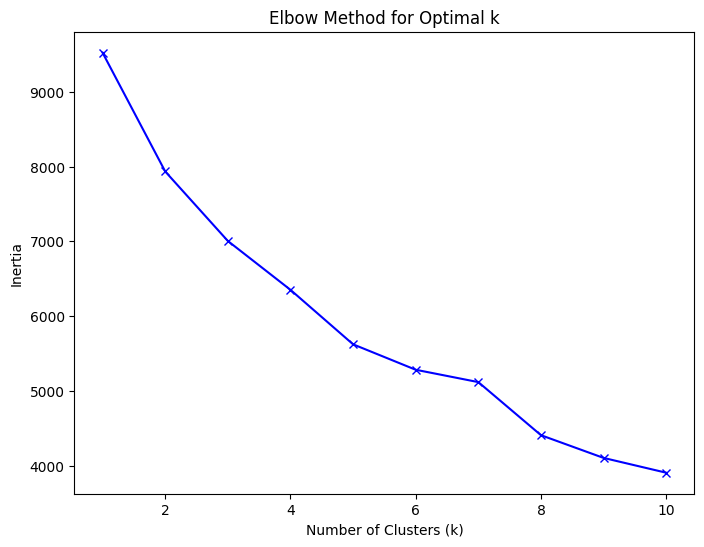

In [339]:
# Scale the selected features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters using elbow method
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

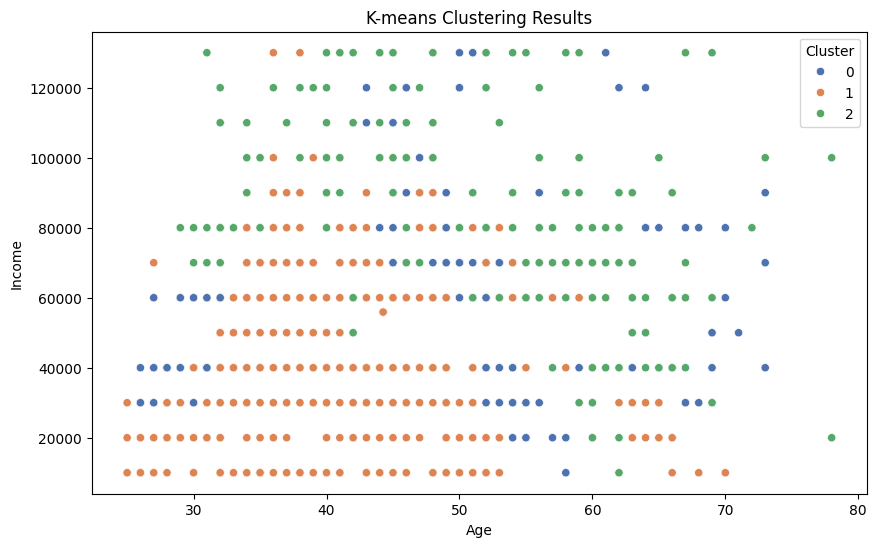

In [340]:
# Train K-means with optimal k (let's assume k=3 based on elbow curve)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
clusters = kmeans.predict(X_scaled)

# Add cluster labels to dataframe
dfd['Cluster'] = clusters

# Visualize clusters (using Age and Income as example, if available in selected features)
plt.figure(figsize=(10, 6))
if 'Age' in dfd.columns:  # Check if Age is still available
    sns.scatterplot(data=dfd, x='Age', y='Income', hue='Cluster', palette='deep')
    plt.title('K-means Clustering Results')
    plt.show()
else:
    print("Note: Age and Income not in selected features for visualization.")

In [341]:
# Cluster analysis
cluster_summary = dfd.groupby('Cluster').agg({
    'Income': 'mean',
    'Age': 'mean',
    'Children': 'mean',
    'Cars': 'mean'
}).round(2)
print("\nCluster Summary Statistics:")
print(cluster_summary)


Cluster Summary Statistics:
           Income    Age  Children  Cars
Cluster                                 
0        58164.30  46.27      1.82  1.89
1        43120.03  40.16      1.43  0.84
2        79164.65  51.26      3.00  2.48


In [342]:
# Model Performance Interpretation
print("\nModel Performance Interpretation:")
print("1. Logistic Regression (Purchased Bike):")
print(f"- Accuracy of {log_accuracy:.4f} shows the proportion of correct predictions")
print("- See classification report for detailed precision, recall, and F1-score by class")

print("\n2. Decision Tree Classifier (Purchased Bike):")
print(f"- Accuracy of {dt_accuracy:.4f} shows the proportion of correct predictions")
print("- See classification report for detailed precision, recall, and F1-score by class")

print("\n3. K-means Clustering:")
print("- Cluster analysis shows distinct customer segments based on selected features")
print("- Visualize clusters to understand customer groupings (if applicable)")


Model Performance Interpretation:
1. Logistic Regression (Purchased Bike):
- Accuracy of 1.0000 shows the proportion of correct predictions
- See classification report for detailed precision, recall, and F1-score by class

2. Decision Tree Classifier (Purchased Bike):
- Accuracy of 1.0000 shows the proportion of correct predictions
- See classification report for detailed precision, recall, and F1-score by class

3. K-means Clustering:
- Cluster analysis shows distinct customer segments based on selected features
- Visualize clusters to understand customer groupings (if applicable)
